In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, auc, confusion_matrix
from sklearn.preprocessing import label_binarize
import fasttext
import numpy as np

In [ ]:
# 1. Load and Clean Dataset
print("Loading and splitting dataset...")
df = pd.read_csv(r"C:\D\file transfer\pp\QueryClassifier\data\QueryDataset140k.csv")
df["query"] = df["query"].str.replace("\n", " ").str.lower().str.strip()
df["fasttext_format"] = "__label__" + df["label"].astype(str) + " " + df["query"]

train_df, test_df = train_test_split(df, test_size=0.1, random_state=42)

train_df["fasttext_format"].to_csv(r"C:\D\file transfer\pp\QueryClassifier\data\fasttext_train.txt", index=False, header=False)
test_df["fasttext_format"].to_csv(r"C:\D\file transfer\pp\QueryClassifier\data\fasttext_test.txt", index=False, header=False)
# Get target classes
classes = sorted(list(df["label"].unique()))
n_classes = len(classes)
print(f"Detected {n_classes} classes: {classes}")

Loading and splitting dataset...


C:\Users\NITRO V 15\AppData\Local\Temp\ipykernel_27920\1722355727.py:3: DtypeWarning: Columns (0: preceding_query) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(r"C:\Users\NITRO V 15\Desktop\QUERYYY\data\QueryDataset140k.csv")


Detected 6 classes: ['comparison', 'follow_up', 'metadata_filter', 'multi_hop', 'retrieval', 'summarization']


Training epoch-by-epoch to generate learning curves...
Epoch 01/05 | Train Acc: 0.9990 | Test Acc: 0.9961
Epoch 02/05 | Train Acc: 0.9991 | Test Acc: 0.9963
Epoch 03/05 | Train Acc: 0.9990 | Test Acc: 0.9963
Epoch 04/05 | Train Acc: 0.9990 | Test Acc: 0.9965
Epoch 05/05 | Train Acc: 0.9990 | Test Acc: 0.9966
Model trained and saved successfully as 'QueryClassifier_6Classes.bin'!

Generating prediction probabilities for ROC-AUC and curves...
Saved accuracy curves to 'metrics\accuracy_curves.png'
Saved ROC curves to 'roc_auc_curves.png'
Saved confusion matrix heatmap to 'metrics//confusion_matrix_heatmap.png'

All visualizations created successfully!


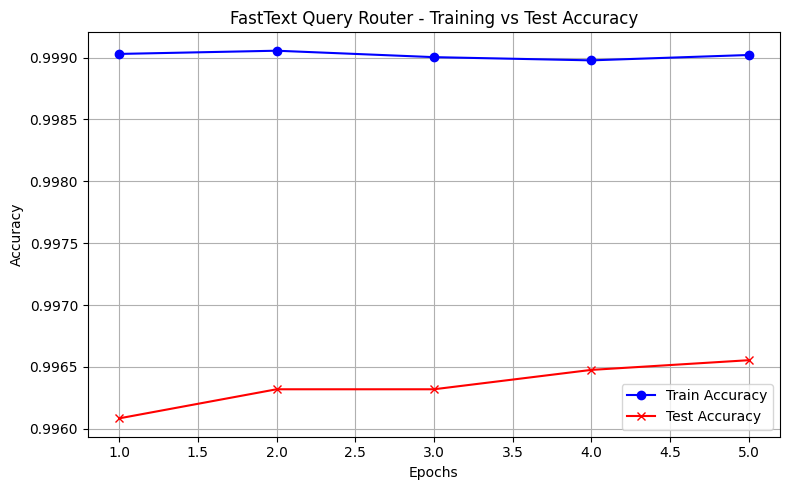

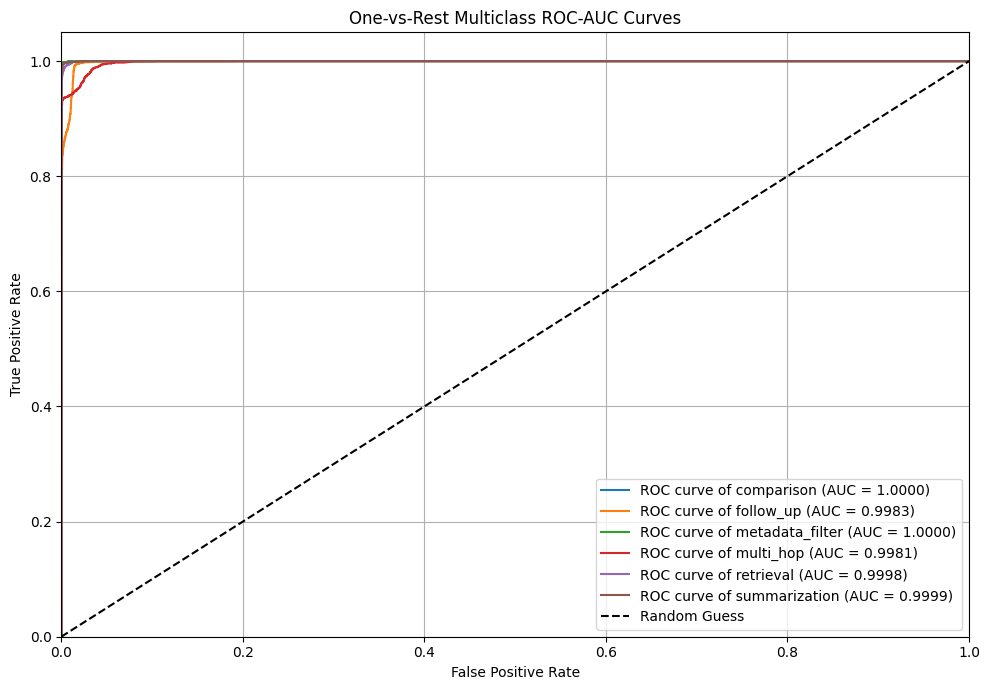

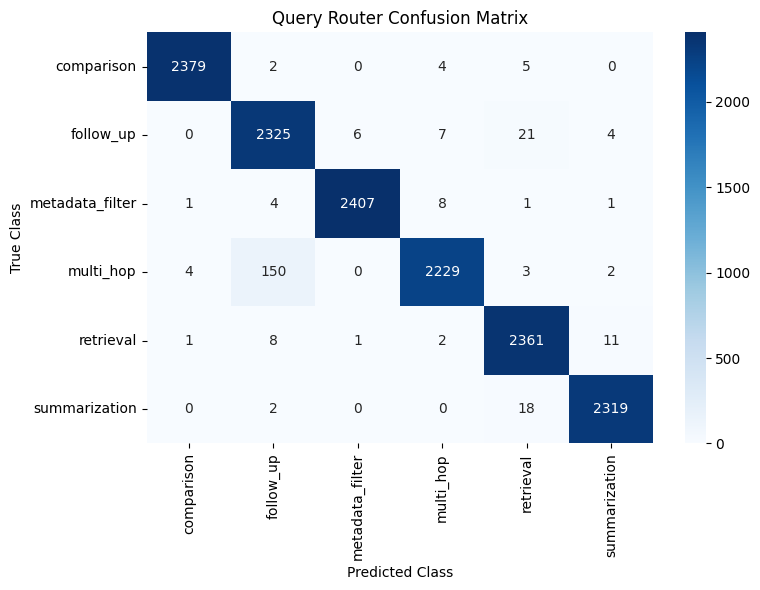

In [ ]:

# 2. Train Epoch-by-Epoch to Capture Training History (Accuracy Curves)
print("Training epoch-by-epoch to generate learning curves...")
epochs = list(range(1, 6))
train_accuracies = []
test_accuracies = []

for e in epochs:
    # Train model up to epoch 'e'
    model = fasttext.train_supervised(
    input=r"C:\D\file transfer\pp\QueryClassifier\data\fasttext_train.txt",
    lr=0.05,        # Slows down learning rate (reduced from 0.5)
    epoch=5,        # 5 epochs is enough to converge without memorizing
    wordNgrams=1,   # Forces learning single words instead of specific 2-word pairs
    minCount=3,     # Ignores rare words that occur less than 3 times
    bucket=200000,
    dim=100,
    loss='softmax'
        )
    
    # Evaluate Train accuracy
    _, train_p, _ = model.test(r"C:\D\file transfer\pp\QueryClassifier\data\fasttext_train.txt")
    train_accuracies.append(train_p)
    
    # Evaluate Test accuracy
    _, test_p, _ = model.test(r"C:\D\file transfer\pp\QueryClassifier\data\fasttext_test.txt")
    test_accuracies.append(test_p)
    print(f"Epoch {e:02d}/05 | Train Acc: {train_p:.4f} | Test Acc: {test_p:.4f}")

# Train the final model to use for ROC and confusion matrix
final_model = model
final_model.save_model(r"C:\D\file transfer\pp\QueryClassifier\model\QueryClassifier_6Classes.bin")
print("Model trained and saved successfully as 'QueryClassifier_6Classes.bin'!")

# 3. Generate Predictions and Probabilities on Test Set
print("\nGenerating prediction probabilities for ROC-AUC and curves...")
y_test = test_df["label"].astype(str).tolist()
y_test_bin = label_binarize(y_test, classes=classes)

y_probs = []
y_pred = []

for query in test_df["query"]:
    labels, probs = final_model.predict(query, k=n_classes)
    
    # Map predictions back to the fixed class order
    prob_dict = {label.replace("__label__", ""): prob for label, prob in zip(labels, probs)}
    y_probs.append([prob_dict.get(c, 0.0) for c in classes])
    y_pred.append(labels[0].replace("__label__", ""))

y_probs = np.array(y_probs)

# 4. Plotting & Saving Figures

# Plot 1: Training Accuracy Curve
plt.figure(figsize=(8, 5))
plt.plot(epochs, train_accuracies, label="Train Accuracy", color="blue", marker="o")
plt.plot(epochs, test_accuracies, label="Test Accuracy", color="red", marker="x")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("FastText Query Router - Training vs Test Accuracy")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(r"C:\D\file transfer\pp\QueryClassifier\metrics\\accuracy_curves.png", dpi=300)
print("Saved accuracy curves to 'metrics\\accuracy_curves.png'")

# Plot 2: Multiclass One-vs-Rest ROC Curve
plt.figure(figsize=(10, 7))
for i, class_name in enumerate(classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"ROC curve of {class_name} (AUC = {roc_auc:.4f})")

plt.plot([0, 1], [0, 1], 'k--', label="Random Guess")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("One-vs-Rest Multiclass ROC-AUC Curves")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.savefig(r"C:\D\file transfer\pp\QueryClassifier\metrics\\roc_auc_curves.png", dpi=300)
print("Saved ROC curves to 'roc_auc_curves.png'")

# Plot 3: Confusion Matrix Heatmap
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(
    cm, 
    annot=True, 
    fmt="d", 
    cmap="Blues", 
    xticklabels=classes, 
    yticklabels=classes
)
plt.ylabel("True Class")
plt.xlabel("Predicted Class")
plt.title("Query Router Confusion Matrix")
plt.tight_layout()
plt.savefig(r"C:\D\file transfer\pp\QueryClassifier\metrics\\confusion_matrix_heatmap.png", dpi=300)
print("Saved confusion matrix heatmap to 'metrics//confusion_matrix_heatmap.png'")

print("\nAll visualizations created successfully!")